In [1]:
import numpy as np
import matplotlib.pyplot as plt

https://machinelearningplus.com/python/numpy-tutorial-part1-array-python-examples/

### 生成array
np.array()

基本属性size,ndim,shape

axis=0 行
axis=1 列
axis=2 纵

A.astype() 类型转换

set_printoptions(suppress=True) 关闭科学技术[其他的一些打印设置]

一旦创建大小不能改变

In [ ]:
# array创建数组
a=np.array([1,2],dtype='int')
a.shape,a.ndim

b=np.array([[1,2],[3,4]])
b.shape,b.size

# matrix 生成二维矩阵
# axis=0 行 axis=1列 axis-轴
A=np.matrix([[1,2],[3,4]])
A

matrix([[1, 2],
        [3, 4]])

### 生成数列
- 等差数列
    - np.arange(start,stop,step) 不包含stop
    - np.linspace(start,stop,num,endpoint) endpoint是否包含结束值

- 等比数列
    - np.logspace(start,stop,num,endpoint,base)

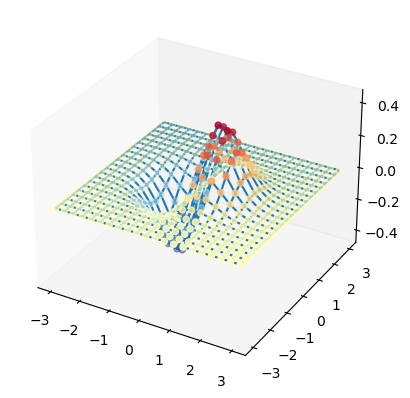

In [7]:
x=np.linspace(-3,3,21)
xx,yy=np.meshgrid(x,x)

xx,yy

fig,ax=plt.subplots(subplot_kw={'projection':'3d'})
ff=xx*np.exp(-xx**2-yy**2)
ax.plot_wireframe(xx,yy,ff,rstride=1,cstride=1)
ax.grid(False)

ax.scatter(xx,yy,ff,cmap='RdYlBu_r',c=ff)

### 特殊生成方法
- np.empty()
- np.empty_like()
- np.eye() 单位矩阵
- np.full() 创建指定大小,给定值的
- np.full_like()
- np.ones()
- np.one_like()
- np.zeros()
- np.zeros_like()

### 排序
- argsort 沿指定轴进行排序
- lexsort 多个间的间接排序
- searchsorted将在排序数组中找元素并
- partition 部分排序

> https://numpy.org/doc/stable/reference/generated/numpy.sort.html#numpy.sort

### 随机数生成
np.random目录下
- uniform 连续均匀分布
- randint 均匀整数
- beta Beta分布
- posisson 泊松分布
- exponential 指数分布
- geometric 几何分布
- binomial 二项分布
- normal 正态分布
- multivariate_normal 多元正态分布
- lognormal 对数正态分布
- standard_t 
- dirichlet

### 持久化
- np.savetxt
- np.genfromtxt

### 特殊行
np.newaxis 特殊列用于增加数组纬度

np.squeeze 挤压,降低纬度[多余]

索引:
- 索引数组 arr[[1,2,3]]
- 索引 arr[::]
- 多维的数组是用arr[,]隔开
    arr[0,0] 取0行0列的一维
    arr[0][0] 单个元素
- ... 表连续::

np.r_ 将切片对象构造成一个数组 [用于创建数组对象],也可以按axis=0拼接数组
np.c_ 按axis=1拼接数组
> r_和c_将切片生成数组

np.ix_() 返回一个二维网格比如(2x2),返回(2,1)*(1,2)

副本:
- copy 深拷贝
- may_share_memory 判断两个内存是否共享



In [60]:
a=np.linspace(1,3,num=3)
a[:,np.newaxis]

a[np.newaxis,:]
b=np.array([[1,2],[1,3]])
b[[1]]

# 反转
a[::-1]

#np.ix_() 将一维数组变成多维数组

np.ix_([1,2],[1,2])

(array([[1],
        [2]]),
 array([[1, 2]]))

### 整形
- reshape/resize 调整形状,resize里不能用-1 [np.reshape(a,-1)变成一维]

### 转置
- np.transpose()
- A.T

### 扁平化
- ravel()
- reshape(-1)
- flatten()

### 翻转,旋转
- rot90
- flip
- fliplr 从左到右翻转
- flipup 从上到下翻转

### 堆叠
- 按垂直方向叠加
    - stack(axis=0)
    - row_stack
    - vstack

- 按水平方向叠加
    - stack(axis=1) 
    - column_stack
    - hstack 

- 拼接
concatenate((),axis=1 or 0) 拼接

### 重复
- repeat 重复元素中每个元素
- tile 重复整个数组

### 分块矩阵
- block 
- split(axis) 将一个数组沿着指定轴分割成多个子数组,
- vsplit 水平分割
- hsplit 垂直分割

> -1在作为形状参数时,会根据数组中的数量和维数来自动计算维度大小

https://numpy.org/doc/stable/reference/routines.array-manipulation.html


np.reshape(a,newshape,order='C') order按顺序存储,C行,F列


In [ ]:
a=np.arange(-7,8)
np.resize(a,(3,5))
b=np.reshape(a,(3,-1))


array([-1])

In [10]:
arr=[[[1, 2], [3, 4]], [[5, 6], [7, 8]]]
np.reshape(arr,(2,-1))

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

### 常见运算
四则运算
- add
- subtract
- multiply
- divide
- power


### 广播机制 - broadcasting

指定不同形状数组之间的运算规则,将形状较小的数组扩展为形状较大的

三条规则
1. 如果两个数组维度不同,会在较小的数组前补1
```
a.shape (3,1)
b.shape (3,) ->自动变成(1,3)
```
2. 逐个维度比较,两个维度相同或则其中一个为1,可以广播
3. 如果某个维度不唯一就抛出异常

In [15]:
a=np.arange(1,4).reshape(3,1)
b=np.arange(1,4)
print(a+b) # 自动补齐+广播

c=np.arange(1,4)
d=c[:, np.newaxis]
print(c+d,c.shape,d.shape) 

[[2 3 4]
 [3 4 5]
 [4 5 6]]
[[2 3 4]
 [3 4 5]
 [4 5 6]] (3,) (3, 1)


### 统计运算
- A.max(axis=,keepdims=True) keepdims保持原数组维度
- np.average(data,axis) 每列平均值 
- np.var(data,axis) 方差
- np.std(data,axis) 标准差
- np.cov(data,ddof) 协方差矩阵ddof计算方差时样本数n,要设置为n-1,ddof=1

### 常见函数
- np.pi 圆周率
- np.e 欧拉数
- np.Inf 正无穷
- np.NAN 非数
- np.power 幂函数
- np.sin/arcsin/cos/arccos/tan/arctan/sinh/cosh/tanh
- np.abs 绝对值
- np.floor 向上取整
- np.ceil 像下取整 
- np.sign 符号函数
- np.exp 指数函数
- np.log 对数函数


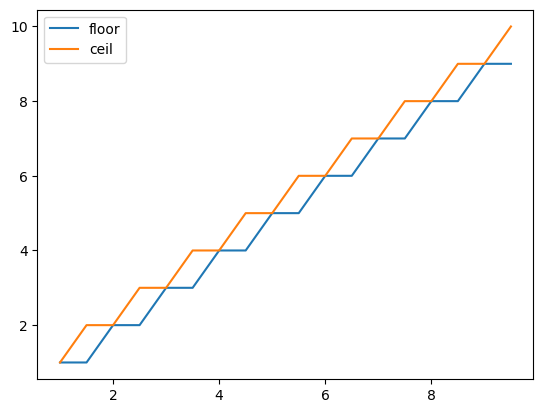

In [25]:
arr=np.arange(1,10,0.5)
fig,ax=plt.subplots()

ax.plot(arr,np.floor(arr),label='floor')
ax.plot(arr,np.ceil(arr),label='ceil')
ax.legend()

### 线性代数
numpy库的linaly模块提供了许多线性代数计算函数
- inv
- pinv moore-penrose 伪逆
- solve
- lstsq 求解最小二乘
- norm 范数
- dot 点击
- cholesky choleshy分解
- eig 特征值和特征向量
- svd 奇异值分解

### 弧度
- arccos 将余旋值转换为弧度(radian)
- rad2deg 将弧度转换角度(degree)

## Advance Index

### 数组索引
- arr[[1,2],[1,2]] 选出(1,1)(2,2)下标下的元素
- arr[[1,2],2] 也可以个标量组合,选出1,2行的第二列

> 里面涉及到广播

https://numpy.org/doc/stable/user/basics.indexing.html#advanced-indexing


- arr[0,1]多维数组进行索引时,可以直接写这样.而不是arr[0][1]这样不仅麻烦而且它效率低,会创建一个临时数组在进行索引;另外如果多维数组进行索引少于它的维度,将会返回一个子数组

- 切片返回的都是试图,不像python里返回的是副本

- `...` 元组索引所需要多少个:对象
  
  `newaxis`(None的别名),根据shape的位置插入列;将数组生维
  `expand_dims()`添加维度
    ``` python
       arr.shape=(3,4) 
       arr[:,:,newaxis].shape=3,4,1 # 2维->3维
       arr[:,newaxis,:].shape=3,1,4
    ```

- 高级索引返回的副本
    - 整数
    - bool

- 索引和切变的变化规律
  1. 整数索引 维度会变
  2. 切片索引 维度保持
  3. 花式/bool 返回新数组

numpy遇到多个索引参数时,会先对他们进行广播处理

- 用了整数？降一维
- 用了切片？保维度
- 用了高级数组？看广播维度[高级索引（整数数组或布尔数组），NumPy 会将所有高级索引广播成共同 shape]
- 混合使用？高级索引决定形状，基础索引插中间
- 结果是不是副本？只要用了高级索引，就是副本

In [49]:
x = np.array([[[1],[2],[3]], [[4],[5],[6]]])
x[:,:,0] # 2,3,1 从外向内看,一层2,二层3,一层1
x.shape
x[2:]

arr=np.arange(1,13).reshape(3,4)
arr[2:5] # i:i+1 返回最后一行

s=(slice(0,1,1),slice(0,1,1))
arr[0:1,0:1]

arr.shape

arr[:,np.newaxis,:].shape,arr[:,np.newaxis,:,None].shape
arr[:,np.newaxis,:],arr[:,None,:].shape
x[:,:].shape,x.ndim

((2, 3, 1), 3)

In [8]:
a=np.arange(1,5)
a[None,:]+a[:,None]

a=np.array([[1,2],[3,4]])
a>2

a[[1],[1]]

a[a>2]
np.ix_([1,2],[3,4])

(array([[1],
        [2]]),
 array([[3, 4]]))

In [44]:
# Advance Index
arr=np.linspace(1,9,num=9).reshape((3,3))
print(arr)
print(arr[(0,2)]) # 选(0,2)的元素
print(arr[(2,2),])

[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
3.0
[[7. 8. 9.]
 [7. 8. 9.]]


In [18]:
# Array Index
a=np.arange(0,12)
x=a.reshape((3,-1))

# 取对角上的4位元素
print('x:',x)
# 1.array index
row=np.array([[0,0],[2,2]],dtype='intp')
col=np.array([[0,3],[0,3]])
print('1.array index:',x[row,col])

# 2.broadcasting [2,1] [1,2] 形态传播
a=np.array([0,2])
col=np.array([0,3])
row=a[:,np.newaxis]
print('2.broadcasing:',x[row,col])


# 3.ix_ 生成二维数组,网状
rows = np.array([0, 2], dtype=np.intp)
columns = np.array([0, 3], dtype=np.intp)
np.ix_(rows,columns)

# 4.高级索引
x[[0,0,2,2],[0,3,0,3]]

x: [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
1.array index: [[ 0  3]
 [ 8 11]]
2.broadcasing: [[ 0  3]
 [ 8 11]]


array([ 0,  3,  8, 11])

In [ ]:
xx=np.arange(27).reshape(3,3,3)
print(xx,xx.shape)
# numpy遇到多个索引参数时,会先对他们进行广播处理
xx[[0, 2],     # 第一个维度（层） → 选取第 0 层和第 2 层 → shape: (2,)
  :       ,   # 第二个维度（行） → 所有行 → shape: (3,)
 [1, 2]]      # 第三个维度（列） → 选第 1 列、第 2 列 → shape: (2,)
xx[[0,2],:,[1,2]] # 选取第0层第0行第1列和第2层第1行第2列

#两个高级索引 [0, 2] 和 [1, 2] 会触发 NumPy 的高级索引广播机制：
#NumPy 会把两个 shape 为 (2,) 的数组广播成 shape (2, 2) 的组合方式。
#然后 NumPy 会根据它们生成索引对：(0,1), (0,2), (2,1), (2,2)。


# 所有高级索引先广播，然后 在所有高级索引出现的位置上插入新维度÷

[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]]

 [[ 9 10 11]
  [12 13 14]
  [15 16 17]]

 [[18 19 20]
  [21 22 23]
  [24 25 26]]] (3, 3, 3)


array([[ 1,  4,  7],
       [20, 23, 26]])

In [64]:
a = np.arange(16).reshape(4, 4)
print(a)
a[[1,2], 1:3] # 
a[1:3,[1,2]] # 不降维度

row=np.array([0,2])
col=np.array([0,2])
row[:,np.newaxis]
col[np.newaxis,:]

a[row[:,np.newaxis],col[np.newaxis,:]] # 选取第0行第0列和第2行第2列

b=np.arange(0,27).reshape(3,3,3)
print(b)
b[0,1:3,1:3] # 切片索引保持维度
b[[0],[1,2],[1,2]] # 

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]]

 [[ 9 10 11]
  [12 13 14]
  [15 16 17]]

 [[18 19 20]
  [21 22 23]
  [24 25 26]]]


array([4, 8])

In [52]:
a = np.arange(24).reshape(2, 3, 4)
print(a)
# 猜猜结果 shape 是多少？
print(a[1].shape)        # ? (3,4)
print(a[1:2].shape)      # ? (1,3,4)
print(a[[1]].shape)      # ? (1,3,4)
print(a[[0, 1], :, [2, 3]].shape)  # ? (2,3)
print(a[:, :, [1]].shape)         # ? (2,3,1)


[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]
(3, 4)
(1, 3, 4)
(1, 3, 4)
(2, 3)
(2, 3, 1)


### bool索引
arr[bool] 它返回的是为True的元素,返回的一维数组

b=arr>1 返回Bool数组,与原来的数组有相同维度

In [42]:
x = np.array([[1., 2.], [np.nan, 3.], [np.nan, np.nan]])
print(x[~np.isnan(x)]) # 返回一维

x=np.array([1,-2,-3,10])
print(x[x<0]+100)

x>1

[1. 2. 3.]
[98 97]


array([False, False, False,  True])

In [ ]:
# 当bool数组维度数少于索引数组时,等效于x[:,...]
x=np.arange(35).reshape(5,7)

b=x>20
x[b] # 返回一维度数组
b[:,1]
x[b[:,1]] # 所有行+true

array([[21, 22, 23, 24, 25, 26, 27],
       [28, 29, 30, 31, 32, 33, 34]])

In [ ]:
x = np.array([[ 0,  1,  2],
              [ 3,  4,  5],
              [ 6,  7,  8],
              [ 9, 10, 11]])

rows = (x.sum(-1) % 2) == 0
cols=np.array([0,1])
x[rows,cols[:,np.newaxis]]

# x[np.ix_(rows,cols)]

x[[1,-1],np.array([0,1])[:,np.newaxis]] # 选取第1行和最后一行的第0列和第1列

array([[ 3,  9],
       [ 4, 10]])

In [ ]:
# 用(2,3)bool索引,从(2,3,5)中选出(4,5)
x=np.arange(30).reshape((2,3,5))
print('x:',x)

# 从x中选出(y,z)
bo=np.array([[True,True,False],[True,False,True]]) #(2,3)
x[bo].shape


x: [[[ 0  1  2  3  4]
  [ 5  6  7  8  9]
  [10 11 12 13 14]]

 [[15 16 17 18 19]
  [20 21 22 23 24]
  [25 26 27 28 29]]]


(4, 5)

### 高级和基础的整合
高级索引和切片分开执行的比如x[1:2,[1,2]] <=> x[1:2,:][:,[1,2]], 先切片在索引

In [ ]:
x=np.arange(12).reshape((3,4))
print('x',x)
x[1:2,[1,2]] # <=> [1,:][:,[1,2]]


x [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


array([[5, 6]])

### flat 属性
返回1-d迭代器

### 索引赋值的
1. 索引出来的数组可以赋值一个常量或者复制给相同形状的值
2. 赋值的类型
a[1]=1

### 处理可变索引
index=(1,1,1,slice(1,2)) <=> (1,1,1,1:2)
x[index]

In [ ]:
# 平面迭代
x=np.arange(16).reshape((4,4))
x.flat

x[1:2,1]=[7] # 赋值形状必须相同

y=np.arange(0,50,10)
y[[1,1,2,1]]+=1 # 只提取了index为1的数据添加到临时数组赋值,在放回原数组
y

array([ 0, 11, 21, 30, 40])

### 常用技巧

1. np.where 

2. np.genfromtxt(path,dilimiter=',',skip_header=1,filling_value=-11,dtype) 类型必须相同,在处理时dtype可设置为Null或者object

3. save存储单个,savez存储多个;load加载.这种存储没有中间过程

4. concatenate(axis);np.r_,np.c_;np.vstack;np.hstack

5. np.sort(arr,axis) 基于某行某列排序

6. np.argsort() 排序返回索引

6. np.lexsort() 基于两个字段排序

7. np.datetime64('2020-01-01 10:10:10','D') 时间对象,D 去时间;np.timedalta64();np.dateime_as_string()转换成str;is_busday()

8. 创建时间序列 np.arange(np.datetime64(),np.datetime64())

9. vectorize 让函数作用于arr里的单个原书 

10. apply_along_axis 让函数作用于axis

11. searchsorted 从排序中找到带插入的位置

12. digitize 查找区间

13. clip(x,3,8) 低的用3代替,高的用8

14. histogram bincount 

15. unique返回唯一的值

> 常用查询 https://numpy.org/doc/stable/reference/routines.html


In [ ]:
# 1.np.where(condtion,value,other)取满足condtion的下标
arr=np.arange(10)

np.where(arr%2==0) # get index

np.where(arr%2==0,1,-1) # if else

arr[np.where(arr%2==0)]


array([0, 2, 4, 6, 8])

In [ ]:
# 2.genfromtxt 可以加载url里的
path = 'auto.cvs'
auto=np.genfromtxt(path,delimiter=',',skip_header=1,filling_values=-999)
auto
# 取dtype=None 保留文本和数字列
auto_txt=np.genfromtxt(path,delimiter=',',skip_header=1,dtype=None)

auto_txt

/var/folders/m4/fgyn19bn1cb4vzrvd9hbd2xr0000gn/T/ipykernel_10213/2524590075.py:6: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.
  auto_txt=np.genfromtxt(path,delimiter=',',skip_header=1,dtype=None)


array([(18. , 8, 307. , 130, 3504, 12. , 70, 1, b'"chevrolet chevelle malibu"'),
       (15. , 8, 350. , 165, 3693, 11.5, 70, 1, b'"buick skylark 320"'),
       (18. , 8, 318. , 150, 3436, 11. , 70, 1, b'"plymouth satellite"'),
       (16. , 8, 304. , 150, 3433, 12. , 70, 1, b'"amc rebel sst"'),
       (17. , 8, 302. , 140, 3449, 10.5, 70, 1, b'"ford torino"'),
       (15. , 8, 429. , 198, 4341, 10. , 70, 1, b'"ford galaxie 500"'),
       (14. , 8, 454. , 220, 4354,  9. , 70, 1, b'"chevrolet impala"'),
       (14. , 8, 440. , 215, 4312,  8.5, 70, 1, b'"plymouth fury iii"'),
       (14. , 8, 455. , 225, 4425, 10. , 70, 1, b'"pontiac catalina"'),
       (15. , 8, 390. , 190, 3850,  8.5, 70, 1, b'"amc ambassador dpl"'),
       (15. , 8, 383. , 170, 3563, 10. , 70, 1, b'"dodge challenger se"'),
       (14. , 8, 340. , 160, 3609,  8. , 70, 1, b'"plymouth \'cuda 340"'),
       (15. , 8, 400. , 150, 3761,  9.5, 70, 1, b'"chevrolet monte carlo"'),
       (14. , 8, 455. , 225, 3086, 10. , 70, 1

In [ ]:
# 3.save,savez,load
arr=np.arange(36)
np.save('arr.npy',arr)

np.load('arr.npy')

In [46]:
# 4. concatenate
a=np.array([1,1,2,2])[np.newaxis,:]
b=np.array([1,1,2,2])[np.newaxis,:]

# 沿着x方向拼接
print('np.concatenate(axis)',np.concatenate((a,b),axis=0))
print('np.vstack',np.vstack((a,b)))
print('np.r_:',np.r_[a,b]) # r_ 用
# 沿着y方向拼接
print('np.concatenate(axi=1)',np.concatenate((a,b),axis=1))
print('np.hstack',np.hstack((a,b)))
print('np.c_',np.c_[a,b])

np.concatenate(axis) [[1 1 2 2]
 [1 1 2 2]]
np.vstack [[1 1 2 2]
 [1 1 2 2]]
np.r_: [[1 1 2 2]
 [1 1 2 2]]
np.concatenate(axi=1) [[1 1 2 2 1 1 2 2]]
np.hstack [[1 1 2 2 1 1 2 2]]
np.c_ [[1 1 2 2 1 1 2 2]]
